# Tutorial 02 — Lead: isolated $sp^3$ MLWFs on a metal

The waw-native reimagining of Wannier90 tutorial 2. **FCC lead**, one atom per cell: 4 $sp^3$-like MLWFs from an **isolated** band manifold (no disentanglement — `num_bands == num_wann`), the same recipe as GaAs (notebook 01) but on a metal instead of a semiconductor. PseudoDojo Pb carries a $5d^{10}$ semicore (14 valence electrons), which we exclude, leaving the $6s6p$-derived manifold as the 4 isolated MLWFs.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged DFT and Wannierisation
FCC Pb, $a = 4.951$ Å, cold smearing (it's a metal). 11 bands (5 $5d$ semicore + 4 target + 2 buffer), exclude bands 1-5 and 10-11, keep the isolated 4-band $6s6p$ manifold.

In [2]:
from ase.build import bulk
atoms = bulk('Pb', 'fcc', a=4.951)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'pb'
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.02)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'pb',
    ecutwfc=50, scf_kpts=(8, 8, 8), nbnd=11, num_wann=4,
    exclude_bands=[1, 2, 3, 4, 5, 10, 11],   # 5d semicore + 2-band buffer
    scdm_entanglement='isolated', system_extra=SMEAR,
    pseudopotentials={'Pb': 'Pb.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/pb/ if present
)
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=4, n_restarts=3, n_iter=5000, verbose=False,
)
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial02: 7.7513)')
print('per-WF spreads (Ang^2):', spreads.round(3))

Omega_total = 7.8474 Ang^2   (Wannier90 tutorial02: 7.7513)
per-WF spreads (Ang^2): [1.962 1.962 1.962 1.962]


4 equivalent $sp^3$-like MLWFs, matching Wannier90's reference closely despite the very different pseudopotential (PseudoDojo's $5d$-semicore-inclusive Pb vs. the classic tutorial's minimal one).

### 2. Interpolated band structure
ASE's standard FCC path: the 4-band model reproduces the isolated $6s6p$ manifold exactly at the mesh points, interpolated everywhere else.

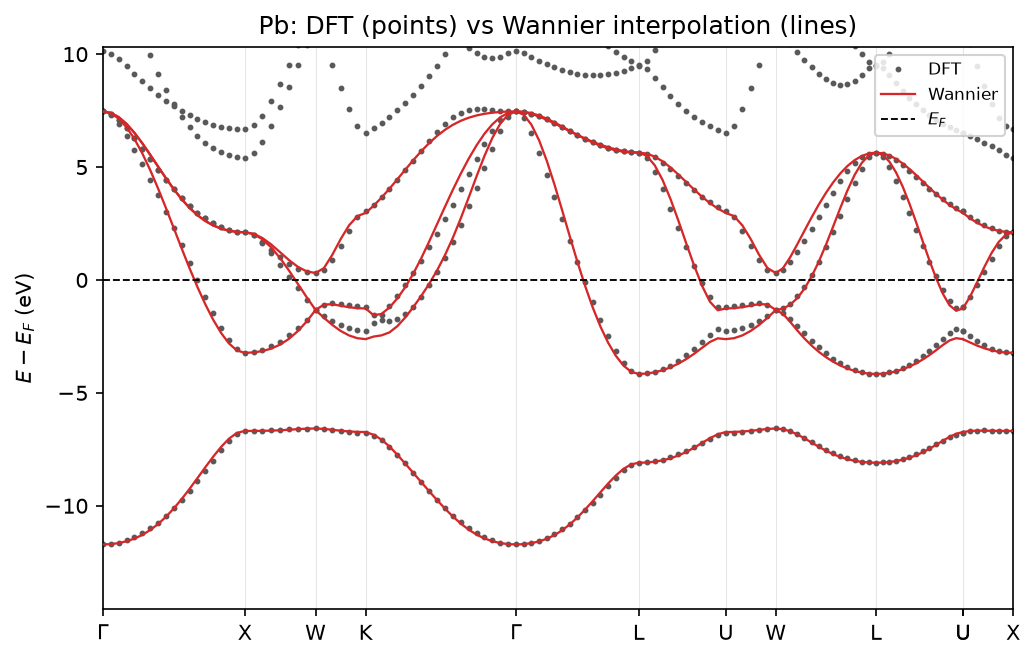

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'pb', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Pb: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


The bands cross $E_F$ — like Cu (notebook 04), Pb is a metal with a genuine Fermi surface; `waw.analysis.fermi_surface`/`write_bxsf` (demonstrated in full, including the 3-D Brillouin-zone rendering, in notebook 04) apply here unchanged, on this simpler *isolated* 4-band model rather than a disentangled 7-band one.

**Takeaway.** An isolated-band metal needs nothing beyond what GaAs's isolated-semiconductor recipe already provides — `exclude_bands` for the semicore, no window, `wannierize()` unchanged.